# Subset Selection, PCR and PLS — An Illustrated Tour

> Inspired by **ISLR Ch. 6** ([book club notes](https://r4ds.github.io/bookclub-islr/linear-model-selection-and-regularization.html)).

Three different ways to fight high variance in $p \approx n$ regression:

1. **Subset selection** — drop predictors entirely (forward / backward stepwise, $C_p$, AIC, BIC).
2. **Shrinkage** — keep all predictors but shrink coefficients (Ridge, Lasso).
3. **Dimension reduction** — project $X$ onto $M < p$ directions, then regress (PCR (Principal Component Regression), PLS (Partial Least Squares)).

## The picture — model complexity vs validation error: Cp/AIC/BIC pick the elbow

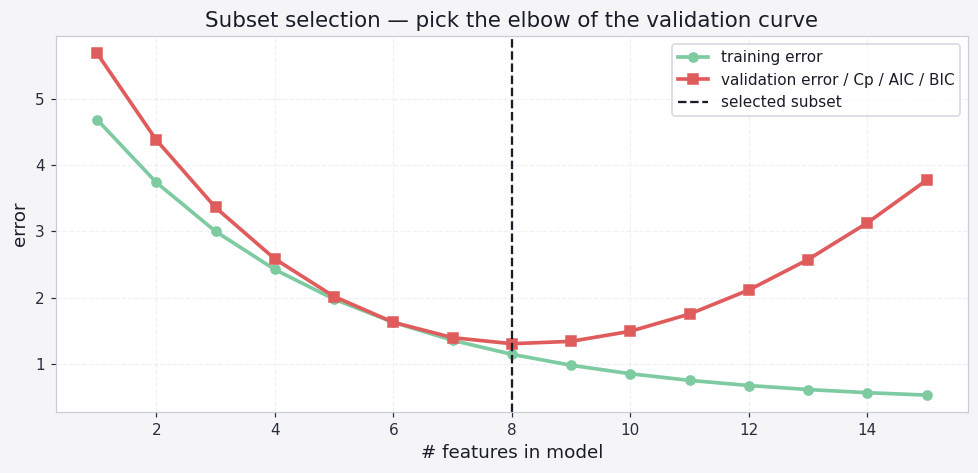

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
p = np.arange(1, 16)
train = 5.5*np.exp(-0.25*p) + 0.4
test  = 5.5*np.exp(-0.25*p) + 0.4 + 0.04*(p-6)**2
fig, ax = plt.subplots(figsize=(9, 4.4))
ax.plot(p, train, color=P[3], lw=2.4, marker='o', label='training error')
ax.plot(p, test,  color=P[1], lw=2.4, marker='s', label='validation error / Cp / AIC / BIC')
ax.axvline(p[np.argmin(test)], color='#1a1d27', ls='--', label='selected subset')
ax.set_xlabel('# features in model'); ax.set_ylabel('error')
ax.set_title('Subset selection — pick the elbow of the validation curve')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

rng = np.random.RandomState(0)
n, p = 80, 20
beta = np.zeros(p); beta[:5] = [3, -2, 1.5, -1, 0.7]   # only 5 features matter
X = rng.randn(n, p); y = X @ beta + rng.randn(n)
print(f'Design: n={n}, p={p}, only 5 informative features')


Design: n=80, p=20, only 5 informative features


---
## 1. Forward stepwise + IC scores

Greedily add the predictor that drops RSS the most.
Compare $C_p \approx \text{RSS} + 2k\hat\sigma^2$, AIC, BIC across model sizes.


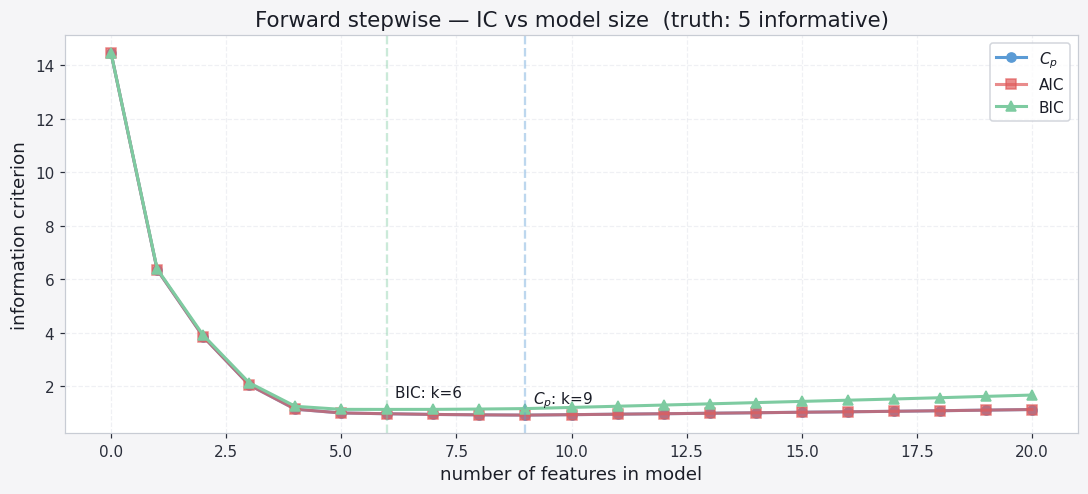

Selection order (first 10): [0, 1, 2, 3, 4, 15, 16, 9, 14, 12]
Truly informative features (0-indexed): [0, 1, 2, 3, 4]


In [3]:
def rss(X_sub, y):
    m = LinearRegression().fit(X_sub, y)
    return np.sum((y - m.predict(X_sub))**2)

selected = []; remaining = list(range(p))
sigma2 = rss(X, y) / (n - p - 1)  # high-D σ² estimate

rss_path = [np.sum((y - y.mean())**2)]   # null model
for _ in range(p):
    best_j, best_rss = None, np.inf
    for j in remaining:
        r = rss(X[:, selected + [j]], y)
        if r < best_rss: best_rss, best_j = r, j
    selected.append(best_j); remaining.remove(best_j); rss_path.append(best_rss)

ks = np.arange(0, p+1)
cp  = (np.array(rss_path) + 2*ks*sigma2) / n
aic = (np.array(rss_path) + 2*ks*sigma2) / n
bic = (np.array(rss_path) + np.log(n)*ks*sigma2) / n

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(ks, cp,  color=PALETTE[0], lw=2, marker='o', label='$C_p$')
ax.plot(ks, aic, color=PALETTE[1], lw=2, marker='s', label='AIC', alpha=0.7)
ax.plot(ks, bic, color=PALETTE[3], lw=2, marker='^', label='BIC')
for arr, name, c in [(cp,'$C_p$',PALETTE[0]),(bic,'BIC',PALETTE[3])]:
    k_star = int(np.argmin(arr))
    ax.axvline(k_star, color=c, ls='--', alpha=0.4)
    ax.annotate(f'{name}: k={k_star}', (k_star, arr.min()), textcoords='offset points', xytext=(5, 8))
ax.set_xlabel('number of features in model'); ax.set_ylabel('information criterion')
ax.set_title('Forward stepwise — IC vs model size  (truth: 5 informative)')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

print('Selection order (first 10):', selected[:10])
print('Truly informative features (0-indexed):', list(range(5)))


---
## 2. PCR vs PLS — dimension reduction approaches

- **PCR**: project $X$ onto its top-$M$ principal components (unsupervised), then regress $y$.
- **PLS**: choose components that **also** correlate with $y$ (supervised).


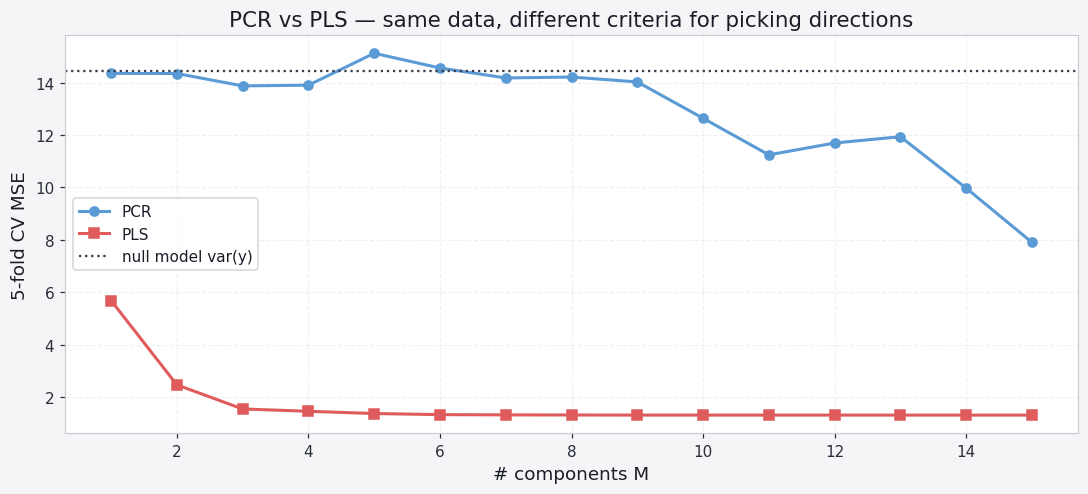

Best PCR M = 15 (MSE 7.902)
Best PLS M = 11 (MSE 1.306)


In [4]:
Ms = list(range(1, 16))
pcr_mse, pls_mse = [], []
for M in Ms:
    pcr = make_pipeline(StandardScaler(), PCA(n_components=M), LinearRegression())
    pls = PLSRegression(n_components=M)
    pcr_mse.append(-cross_val_score(pcr, X, y, cv=5, scoring='neg_mean_squared_error').mean())
    pls_mse.append(-cross_val_score(pls, X, y, cv=5, scoring='neg_mean_squared_error').mean())

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(Ms, pcr_mse, color=PALETTE[0], lw=2, marker='o', label='PCR')
ax.plot(Ms, pls_mse, color=PALETTE[1], lw=2, marker='s', label='PLS')
ax.axhline(np.var(y), color='#3a3e4a', ls=':', label='null model var(y)')
ax.set_xlabel('# components M'); ax.set_ylabel('5-fold CV MSE')
ax.set_title('PCR vs PLS — same data, different criteria for picking directions')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()
print(f'Best PCR M = {Ms[int(np.argmin(pcr_mse))]} (MSE {min(pcr_mse):.3f})')
print(f'Best PLS M = {Ms[int(np.argmin(pls_mse))]} (MSE {min(pls_mse):.3f})')


---
## What we just saw

- **Forward stepwise + BIC** correctly picked a model close to the truth (~5 features). $C_p$/AIC tend to keep more predictors than BIC because their penalty is lighter.
- **PLS** typically reaches a lower MSE with **fewer components** than PCR, because it actively chooses directions correlated with $y$.
- For very correlated predictors, **all three families work** — the choice is a matter of interpretability (subset = sparsity, shrinkage = stability, dim-reduction = compression).

> Lesson: in $p \gg n$ or near-collinear settings, you must constrain the model. The three constraint flavours each shine in a different regime.
